<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/Prueba_Kolmogorov_Smirnov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:green;">PRUEBA DE KOLMOGOROV-SMIRNOV </span>
<span style="color:purple;"></span>



La prueba de Kolmogorov--Smirnov (K--S) es una prueba estadística no
paramétrica que se utiliza para determinar si un conjunto de datos
proviene de una distribución teórica específica, o para comparar si
dos muestras provienen de la misma distribución.

En el contexto de simulación, esta prueba se emplea frecuentemente
para verificar si un conjunto de números pseudoaleatorios sigue una
distribución uniforme $U(0,1)$.


<span style="color:orange;">**Idea fundamental**</span>

La prueba se basa en comparar:



*   La función de distribución acumulada empírica (FDAE) de la muestra, denotada como $F_n(x)$.
*   La función de distribución acumulada teórica, denotada como $F(x)$




La función de distribución empírica se define como:


$$ F_n(x) = \frac{\text{Número de observaciones } \leq x}{n}$$


<span style="color:orange;">**Hipótesis**</span>



$$ H_0: F_n(x) = F(x) \quad \text{(La muestra sigue la distribución teórica)}$$



$$H_1: F_n(x) \neq F(x)$$


<span style="color:orange;">**Estadístico de prueba**</span>


El estadístico de Kolmogorov--Smirnov se define como la máxima diferencia
absoluta entre ambas funciones:


$$D_n = \sup_x \left| F_n(x) - F(x) \right|$$


Es decir, se calcula la mayor distancia vertical entre la distribución
empírica y la distribución teórica.


<span style="color:orange;">**Regla de decisión**</span>


Para un nivel de significancia $\alpha$, se compara $D_n$ con un valor
crítico $D_{\alpha}$:




*   Si $D_n > D_{\alpha}$, se rechaza $H_0$
*   Si $D_n \leq D_{\alpha}$, no se rechaza $H_0$



In [30]:
import numpy as np  #Calculo simbolico
from scipy.stats import kstest, ksone
import pandas as pd #Permite leer y escribir fácilmente ficheros en formato CSV, Excel y bases de datos SQL
from tabulate import tabulate #Esta libreria sirve para crear tablas
import matplotlib.pyplot as plt # Importar matplotlib para graficar


En esta prueba ordenamos la muestra $X_m$ , de menor a mayor y comparamos la frecuencia observada contra la frecuencia esperada; es decir comparamos contra la Distribución Acumulativa $F(x)$

Dada una muestra $X_n$ de prueba.

Establecemos:
$$H_0:X_n ∼ U(0,1)$$

$$
H_1:X_n \nsim U(0,1)
$$

Ahora bien, Ordenamos los numeros de la muestraen orden ascendente

In [31]:
datos = sorted([ #Datos de la tabla 3.1 de los numeros pseudoaleatorios
0.78961, 0.05230, 0.10699, 0.55877, 0.14151,
0.76086, 0.12079, 0.27738, 0.65726, 0.79269,
0.80548, 0.82654, 0.29453, 0.20852, 0.42989,
0.58518, 0.98611, 0.34488, 0.34358, 0.11537,
0.89898, 0.57880, 0.67621, 0.05010, 0.00121,
0.28269, 0.73059, 0.70119, 0.18284, 0.49962,
0.38618, 0.76910, 0.68334, 0.55170, 0.10850,
0.79882, 0.45679, 0.21631, 0.87616, 0.55743,
0.58962, 0.33216, 0.03185, 0.61168, 0.09264,
0.69623, 0.17028, 0.05475, 0.91512, 0.76262,
0.29931, 0.30861, 0.83358, 0.51781, 0.03272,
0.57410, 0.26593, 0.85903, 0.43308, 0.35286,
0.24000, 0.65559, 0.38507, 0.90829, 0.94187,
0.93655, 0.88809, 0.81772, 0.36982, 0.19904,
0.54325, 0.62400, 0.09133, 0.41678, 0.33954,
0.58244, 0.85853, 0.86752, 0.38729, 0.15506,
0.23949, 0.53559, 0.33381, 0.49883, 0.75103,
0.19962, 0.65002, 0.74579, 0.79113, 0.63453,
0.19147, 0.40644, 0.08128, 0.73435, 0.22724,
0.22287, 0.07281, 0.64183, 0.44267, 0.72102
]) #sorted devuelve Datos ordenados

In [32]:
datos_ordenados = np.sort(datos) #Esta es optra forma de ordenar los datos
n = len(datos)
alpha = 0.5
# Función de distribución uniforme teórica F0(x) = x para U(0,1)
F0 = datos_ordenados

Función de distribución empírica $Fn(x)$

In [33]:
# Para cada punto, Fn(x) = i/n, donde i es la posición
indices = np.arange(1, n + 1)
Fn_antes = (indices - 1) / n  # Fn justo antes del punto
Fn_despues = indices / n      # Fn en el punto

Calculamos el estadístico de prueba D a partir de:

Estadístico $D_n^+$ (máxima desviación por arriba)
$$
D_n^+ = \max_{1 \leq i \leq n} \left\{ \frac{i}{n} - F_0(x_{(i)}) \right\}
$$

Estadístico $D_n^-$ (máxima desviación por debajo)

$$
D_n^- = \max_{1 \leq i \leq n} \left\{ F_0(x_{(i)}) - \frac{i-1}{n} \right\}
$$

Estadístico $D_n$ (bilateral)

$$
D_n = \max(D_n^+, D_n^-)
$$

O en términos de datos ordenados:

$$
D_n = \max_{1 \leq i \leq n} \left\{ \max\left( \left| \frac{i}{n} - F_0(x_{(i)}) \right|, \left| F_0(x_{(i)}) - \frac{i-1}{n} \right| \right) \right\}
$$

Donde $i$ es la posición de $x_i$


In [34]:
# Calcular D+ y D-
D_plus = Fn_despues - F0
D_minus = F0 - Fn_antes

In [35]:
#valores críticos
D_plus_max_idx = np.argmax(D_plus) #estas son las formulas descritas arriba
D_minus_max_idx = np.argmax(D_minus)
D_plus_max_valor = D_plus[D_plus_max_idx]
D_minus_max_valor = D_minus[D_minus_max_idx]
D_max = max(D_plus_max_valor, D_minus_max_valor)

In [36]:
# Crear tabla de resultados
tabla = pd.DataFrame({
    'i': indices,
    'x(i)': datos_ordenados,
    'F0(x)': F0,
    'i/n': Fn_despues,
    '(i-1)/n': Fn_antes,
    'D+ = i/n - F0(x)': D_plus,
    'D- = F0(x) - (i-1)/n': D_minus
})

Este paso lo podemos omitir pero nos sirve para tener una tabla y formatos mas limpios

In [37]:
# Formatear para mostrar
tabla_limpia= tabla.copy()
for col in ['x(i)', 'F0(x)', 'i/n', '(i-1)/n', 'D+ = i/n - F0(x)', 'D- = F0(x) - (i-1)/n']:
    tabla_limpia[col] = tabla_limpia[col].apply(lambda x: f'{x:.4f}')

Creamos la tabla

In [38]:
# Mostrar tabla
print("\n" + "="*100)
print("TABLA DE CÁLCULO KOLMOGOROV-SMIRNOV")
print("="*100)
print(tabulate(tabla_limpia, headers='keys', tablefmt='fancy_grid', showindex=False))

# Prueba de Kolmogorov-Smirnov con scipy
statistic, p_value = kstest(datos, 'uniform')

# Valor crítico para α=0.05 (aproximación para n grande)
alpha = 0.05
D_critico = 1.36 / np.sqrt(n)  # Aproximación para n>50


TABLA DE CÁLCULO KOLMOGOROV-SMIRNOV
╒═════╤════════╤═════════╤═══════╤═══════════╤════════════════════╤════════════════════════╕
│   i │   x(i) │   F0(x) │   i/n │   (i-1)/n │   D+ = i/n - F0(x) │   D- = F0(x) - (i-1)/n │
╞═════╪════════╪═════════╪═══════╪═══════════╪════════════════════╪════════════════════════╡
│   1 │ 0.0012 │  0.0012 │  0.01 │      0    │             0.0088 │                 0.0012 │
├─────┼────────┼─────────┼───────┼───────────┼────────────────────┼────────────────────────┤
│   2 │ 0.0319 │  0.0319 │  0.02 │      0.01 │            -0.0119 │                 0.0219 │
├─────┼────────┼─────────┼───────┼───────────┼────────────────────┼────────────────────────┤
│   3 │ 0.0327 │  0.0327 │  0.03 │      0.02 │            -0.0027 │                 0.0127 │
├─────┼────────┼─────────┼───────┼───────────┼────────────────────┼────────────────────────┤
│   4 │ 0.0501 │  0.0501 │  0.04 │      0.03 │            -0.0101 │                 0.0201 │
├─────┼────────┼─────────┼───────

Grafica de la prueba de Kolmogorov Smirnov

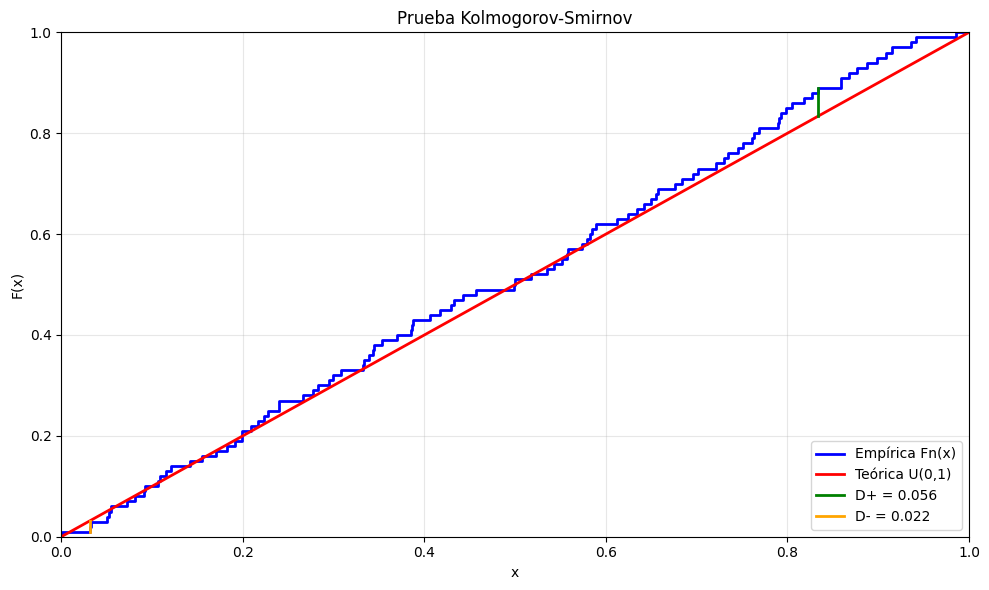

In [39]:
# Crear figura
fig, ax = plt.subplots(figsize=(10, 6))

# Función de distribución empírica
x_empirica = np.concatenate(([0], np.sort(datos), [1]))
y_empirica = np.concatenate(([0], np.arange(1, len(datos)+1)/len(datos), [1]))

# Graficar
ax.step(x_empirica, y_empirica, 'b-', linewidth=2, where='post', label='Empírica Fn(x)')
ax.plot([0, 1], [0, 1], 'r-', linewidth=2, label='Teórica U(0,1)')

# D+ máximo
ax.plot([x_empirica[D_plus_max_idx+1], x_empirica[D_plus_max_idx+1]],
        [x_empirica[D_plus_max_idx+1], y_empirica[D_plus_max_idx+1]],
        'g-', linewidth=2, label=f'D+ = {D_plus_max_valor:.3f}')

# D- máximo
ax.plot([x_empirica[D_minus_max_idx+1], x_empirica[D_minus_max_idx+1]],
        [y_empirica[D_minus_max_idx], x_empirica[D_minus_max_idx+1]],
        'orange', linewidth=2, label=f'D- = {D_minus_max_valor:.3f}')

ax.set_xlabel('x')
ax.set_ylabel('F(x)')
ax.set_title('Prueba Kolmogorov-Smirnov')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

 Procederemos a comparar con el valor crítico $d_{α}n$

si $D<d_{α}n$ se rechaza

In [40]:
from tabulate import tabulate
import numpy as np
from scipy.stats import kstest

# Prueba de Kolmogorov-Smirnov con scipy
statistic, p_value = kstest(datos, 'uniform')

# Nivel de significancia
alpha = 0.05
n = len(datos)
D_critico = 1.36 / np.sqrt(n)  # Aproximación válida para n > 50

# Decisión usando D crítico
if D_max > D_critico:
    decision_D = "Se RECHAZA H0"
else:
    decision_D = "No se rechaza H0"

# Decisión usando valor-p (más formal)
if p_value < alpha:
    decision_p = "Se RECHAZA H0"
else:
    decision_p = "No se rechaza H0"

# Interpretación final
if decision_D == "Se RECHAZA H0":
    conclusion = "Los datos NO siguen una distribución U(0,1)"
else:
    conclusion = "Los datos podrían seguir una distribución U(0,1)"

# Crear tabla de resultados
tabla_resultados = [
    ["Nivel de significancia (α)", f"{alpha}"],
    ["Tamaño de muestra (n)", f"{n}"],
    ["D crítico", f"{D_critico:.5f}"],
    ["Estadístico KS (scipy)", f"{statistic:.5f}"],
    ["Valor p", f"{p_value:.5f}"],
    ["D+ máximo", f"{D_plus_max_valor:.5f}"],
    ["D- máximo", f"{D_minus_max_valor:.5f}"],
    ["D = max(D+, D-)", f"{D_max:.5f}"],
    ["Decisión (con D crítico)", decision_D],
    ["Decisión (con valor-p)", decision_p],
    ["Conclusión final", conclusion]
]

# Mostrar tabla
print("\n" + "="*100)
print("RESULTADOS DE LA PRUEBA KOLMOGOROV-SMIRNOV")
print("="*100)
print(tabulate(tabla_resultados,
               headers=["Concepto", "Resultado"],
               tablefmt="fancy_grid",
               showindex=False))


RESULTADOS DE LA PRUEBA KOLMOGOROV-SMIRNOV
╒════════════════════════════╤══════════════════════════════════════════════════╕
│ Concepto                   │ Resultado                                        │
╞════════════════════════════╪══════════════════════════════════════════════════╡
│ Nivel de significancia (α) │ 0.05                                             │
├────────────────────────────┼──────────────────────────────────────────────────┤
│ Tamaño de muestra (n)      │ 100                                              │
├────────────────────────────┼──────────────────────────────────────────────────┤
│ D crítico                  │ 0.13600                                          │
├────────────────────────────┼──────────────────────────────────────────────────┤
│ Estadístico KS (scipy)     │ 0.05642                                          │
├────────────────────────────┼──────────────────────────────────────────────────┤
│ Valor p                    │ 0.88987                

Como podemos ver, nosotros al ejecutar el código, se obtiene una tabla organizada que resume los
resultados de la prueba de Kolmogorov--Smirnov aplicada al conjunto de datos.

En la tabla se reflejan los siguientes elementos:



*   El nivel de significancia utilizado ($\alpha = 0.05$)
*   El tamaño de la muestra ($n$)
*   El valor crítico $D_{\alpha}$ calculado mediante la aproximación
    $\displaystyle D_{\alpha} = \frac{1.36}{\sqrt{n}}$
*   El estadístico de prueba calculado por \texttt{scipy}
*   El valor-$p$, que mide la evidencia estadística contra la hipótesis nula.
*   Los valores máximos de $D^+$ y $D^-$
*   El estadístico final $D = \max(D^+, D^-)$


Posteriormente, el programa muestra la decisión bajo dos criterios:


*   Comparando $D$ con el valor crítico.
*   Comparando el valor-$p$ con el nivel de significancia $\alpha$.


Finalmente, se presenta una conclusión clara e interpretativa que indica si
los datos pueden considerarse consistentes con una distribución uniforme
$U(0,1)$ o si existe evidencia suficiente para rechazar dicha hipótesis.

En términos prácticos, la tabla permite visualizar de manera estructurada
todo el análisis estadístico realizado, facilitando la interpretación de los
resultados y proporcionando una presentación formal adecuada para reportes
académicos o técnicos.


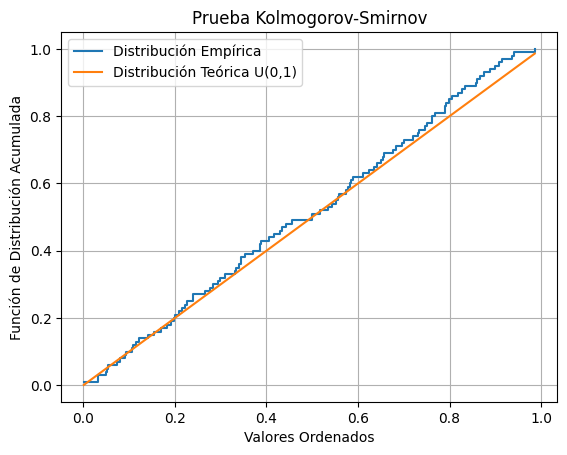

In [29]:



# Ordenar los datos
datos_ordenados = np.sort(datos)
n = len(datos_ordenados)

# Función de distribución empírica
F_empirica = np.arange(1, n+1) / n

# Función de distribución teórica U(0,1)
F_teorica = datos_ordenados  # Para uniforme(0,1), F(x)=x

# Crear gráfica
plt.figure()
plt.step(datos_ordenados, F_empirica, where='post', label='Distribución Empírica')
plt.plot(datos_ordenados, F_teorica, label='Distribución Teórica U(0,1)')

plt.title('Prueba Kolmogorov-Smirnov')
plt.xlabel('Valores Ordenados')
plt.ylabel('Función de Distribución Acumulada')
plt.legend()
plt.grid(True)
plt.show()

<span style="color:blue">**Conclusión:**</span>

Los resultados obtenidos nos permiten tener confianza en el comportamiento
del conjunto de datos analizado. Las pruebas de uniformidad indican que
no existe evidencia estadística suficiente para rechazar que los números
provienen de una distribución $U(0,1)$.

En términos más sencillos, los datos se comportan como esperaríamos de un
generador adecuado de números pseudoaleatorios. Las pequeñas diferencias
observadas no son señales de error o sesgo, sino variaciones naturales
propias del azar.

Para propósitos de simulación y modelado, esto es una buena noticia: el
conjunto presenta un comportamiento aceptable y coherente con los supuestos
teóricos.

Es importante recordar que esta conclusión se establece bajo un nivel de
significancia $\alpha = 0.05$, el cual representa un criterio estándar en
la práctica estadística. Esto significa que aceptamos un pequeño margen
de incertidumbre (5\%) al tomar la decisión, algo completamente normal en
el análisis de datos reales.
